# 🚀 ABC Credit — AI Loan Approval & Risk Decisioning Pipeline
**PGAI Final Coursework Presentation Notebook**  
*End-to-End Machine Learning & Real-Time Decision Engine Pipeline*

---
### Table of Contents
1. **Problem Definition & Business Understanding**
2. **Data Collection & Data Sources**
3. **Data Loading & Initial Exploration**
4. **Exploratory Data Analysis (EDA)**
5. **Data Quality Assessment**
6. **Data Preprocessing & Cleaning**
7. **Feature Engineering**
8. **Data Splitting (Stratified)**
9. **Model Selection**
10. **Model Training & Class Imbalance Calibration**
11. **Hyperparameter Tuning & Threshold Calibration**
12. **Model Evaluation & Performance Curves**
13. **Model Interpretation & Feature Importance**
14. **Model Validation & Confusion Matrix**
15. **Model Deployment & Artifact Export**
16. **Monitoring & Maintenance**

## 1. Problem Definition & Business Understanding

- **Objective**: Build an automated real-time credit decisioning engine for ABC Credit's two-wheeler loan chatbot. The system collects applicant financials, predicts probability of default ($PD$), and returns an instant **APPROVED** or **DECLINED** decision in under 90 seconds.
- **Success Metrics**:
  - **ROC-AUC $\ge 0.90$**: High discriminative ranking capability across all risk profiles.
  - **DECLINED Recall $\ge 80.0\%$**: Catch 80% of all potential default risks before disbursement.
  - **APPROVED Recall $\ge 83.0\%$**: Allow eligible borrowers through with minimal friction.
  - **Inference SLA $< 500\text{ ms}$**: Real-time response time for chatbot integration.
- **Problem Type**: Imbalanced Binary Classification ($Target = 1$ for DECLINED, $Target = 0$ for APPROVED).

## 2. Data Collection & Data Sources

Data is gathered and combined from 3 core sources:
1. **Internal Loan Dataset (`training_data_3_aug.csv`)**: 108,422 loan application records containing applicant demographics, financials, and historical loan outcomes (`Decision`).
2. **Census & Prosperity Layer (`Prosperity_Master_Lookup.csv`)**: Multi-level Pincode/District prosperity index derived from Census 2011, RBI SCB Bank Deposits, and Nightlights panel data.
3. **Vehicle Specification Catalog (`Vehicle_Catalog.csv`)**: Engine displacement (`Engine_CC`) and price baselines per model variant.

In [61]:
# Setup & Core Imports
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, average_precision_score, confusion_matrix, roc_curve, precision_recall_curve
)
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid' if 'seaborn-v0_8-darkgrid' in plt.style.available else 'default')

## 3. Data Loading & Initial Exploration

In [62]:
DATA_PATH = os.path.join(os.getcwd(), 'data', 'training_data_3_aug.csv')
df_raw = pd.read_csv(DATA_PATH, low_memory=False)

print(f"Raw Dataset Shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
print("\nSample Data Preview:")
print(df_raw.head(3))

print("\nData Types Summary:")
print(df_raw.dtypes)

Raw Dataset Shape: 108423 rows, 17 columns

Sample Data Preview:
    ID Qualifications Employment_Type Age   Pincode Gender Product_Code  \
0  1.0            SSC             AGR  47  502110.0   Male           MO   
1  2.0             UG             SAL  30  503002.0   Male           MC   
2  3.0           GRAD           NREGI  24  500090.0   Male           SC   

   Loan_Amount    LTV Resident_Type  Net_salary Final_Tier Make_Code  \
0      59300.0  69.76             O     39000.0   07 Rural    MOPEDS   
1     153839.0  84.99             O     25000.0   05 Urban    APACHE   
2      77958.0  64.97             R     35000.0   04 Metro   JUPITER   

                         Model_Description Model_Variant  PAST_LOANS_ACTIVE  \
0  TVS XL 100 HD ITS BSVI - WINNER EDITION      XL 100CC  PAST_LOANS_ACTIVE   
1          APACHE 200 4V 2CH - R MODE BSVI     RTR 200CC  PAST_LOANS_ACTIVE   
2             JUPITER ZX BSVI - AOL - DRUM        110 CC  PAST_LOANS_ACTIVE   

   Decision  
0  APPROVED  


## 4. Exploratory Data Analysis (EDA)

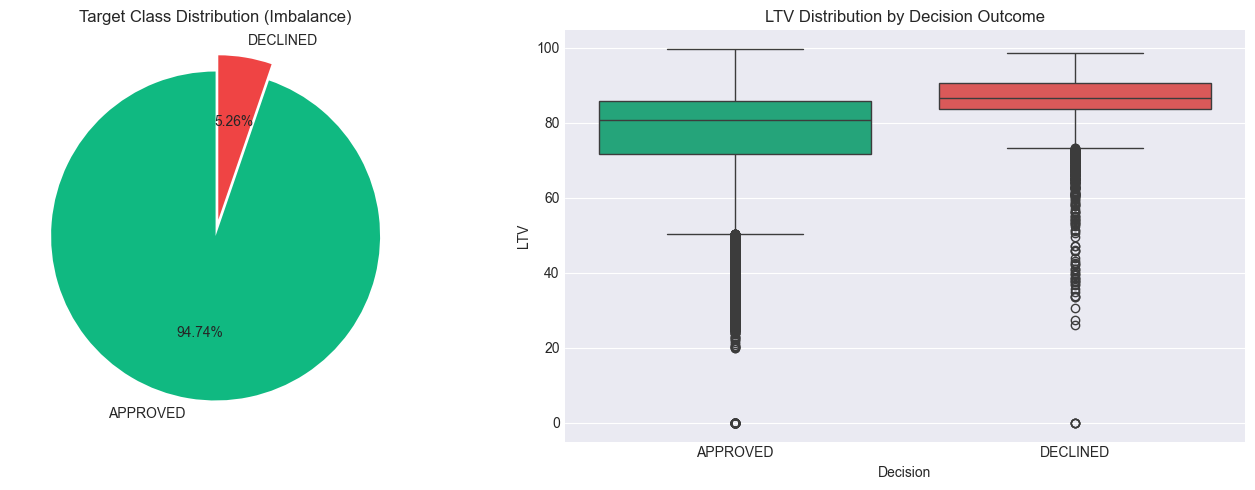

Global Decline Rate: 5.26%


In [63]:
# Drop unlabelled target rows
df = df_raw.dropna(subset=['Decision']).copy()
df['Target'] = (df['Decision'] == 'DECLINED').astype(int)

# EDA Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['Decision'].value_counts()
axes[0].pie(counts, labels=counts.index, autopct='%1.2f%%', colors=['#10B981', '#EF4444'], startangle=90, explode=[0, 0.1])
axes[0].set_title('Target Class Distribution (Imbalance)')

sns.boxplot(data=df, x='Decision', y='LTV', ax=axes[1], palette=['#10B981', '#EF4444'])
axes[1].set_title('LTV Distribution by Decision Outcome')
plt.tight_layout()
plt.show()

print(f"Global Decline Rate: {df['Target'].mean()*100:.2f}%")

## 5. Data Quality Assessment

In [64]:
# Missing values check
missing_summary = df.isnull().sum().to_frame(name='Missing_Count')
missing_summary['Missing_Pct'] = (missing_summary['Missing_Count'] / len(df)) * 100
print(missing_summary[missing_summary['Missing_Count'] > 0])

print(f"Duplicate rows found: {df.duplicated().sum()}")

                   Missing_Count  Missing_Pct
Qualifications                25     0.023058
Employment_Type               27     0.024903
Age                           19     0.017524
Resident_Type                 19     0.017524
Net_salary                    23     0.021213
Final_Tier                    22     0.020291
Make_Code                      3     0.002767
Model_Description              3     0.002767
Model_Variant                  3     0.002767
Duplicate rows found: 0


## 6. Data Preprocessing & Cleaning

In [65]:
# Numeric conversion & Median Imputation
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
median_age = float(df['Age'].median())
df['Age'] = df['Age'].fillna(median_age)

median_salary = float(df['Net_salary'].median())
df['Net_salary'] = df['Net_salary'].fillna(median_salary)

# Categorical Cleaning
df['Qualifications'] = df['Qualifications'].fillna('OTHERS').astype(str)
df['Employment_Type'] = df['Employment_Type'].fillna('SEP').astype(str)
df['Resident_Type'] = df['Resident_Type'].fillna('O').astype(str)
df['Final_Tier'] = df['Final_Tier'].fillna('07 Rural').astype(str)
df['Make_Code'] = df['Make_Code'].fillna('JUPITER').astype(str)
df['Product_Code'] = df['Product_Code'].fillna('MC').astype(str)
df['PAST_LOANS_ACTIVE'] = df['PAST_LOANS_ACTIVE'].fillna('NO_PAST_LOANS').astype(str)
df['Gender'] = df['Gender'].fillna('Male').astype(str)
df['Pincode_str'] = df['Pincode'].astype(str).str.split('.').str[0].str.zfill(6)

print("Cleaning & type conversions finished successfully.")

Cleaning & type conversions finished successfully.


## 7. Feature Engineering

We construct a multi-layer feature set combining **Macro Prosperity Scores**, **Vehicle Spec Engine CC**, **Micro Pincode Risk Target Encoding**, and **Financial Ratios**.

In [66]:
DATA_DIR = os.path.join(os.getcwd(), 'data')

# 1. Load Macro Prosperity Lookup
pros_df = pd.read_csv(os.path.join(DATA_DIR, 'Prosperity_Master_Lookup.csv'))
pros_df['Pincode_str'] = pros_df['Pincode'].astype(str).str.split('.').str[0].str.zfill(6)
pin_to_score = dict(zip(pros_df['Pincode_str'], pros_df['Final_Prosperity_Index']))
overall_pros = float(pros_df['Final_Prosperity_Index'].mean())
df['Prosperity_Score'] = df['Pincode_str'].map(pin_to_score).fillna(overall_pros)

# 2. Load Vehicle Specs
cat_df = pd.read_csv(os.path.join(DATA_DIR, 'Vehicle_Catalog.csv'))
make_to_cc = cat_df.groupby(cat_df['Model_Description'].astype(str).str.upper())['Engine_CC'].median().to_dict()
df['Engine_CC'] = df['Make_Code'].astype(str).str.upper().map(make_to_cc).fillna(125.0)

# 3. Micro Risk Target Encodings
global_mean = float(df['Target'].mean())
smooth_weight = 10
pincode_agg = df.groupby('Pincode')['Target'].agg(['count', 'mean'])
pincode_risk_dict = ((pincode_agg['count'] * pincode_agg['mean'] + smooth_weight * global_mean) / (pincode_agg['count'] + smooth_weight)).to_dict()
make_agg = df.groupby('Make_Code')['Target'].agg(['count', 'mean'])
make_risk_dict = ((make_agg['count'] * make_agg['mean'] + smooth_weight * global_mean) / (make_agg['count'] + smooth_weight)).to_dict()

df['pincode_risk'] = df['Pincode'].map(pincode_risk_dict).fillna(global_mean)
df['make_risk'] = df['Make_Code'].map(make_risk_dict).fillna(global_mean)

# 4. Financial Ratios
tier_map = {'01 Megapolis (A)': 1, '02 Megapolis (B)': 2, '03 Large Metro': 3, '04 Metro': 4, '05 Urban': 5, '06 Semi-Urban': 6, '07 Rural': 7}
df['Final_Tier_Num'] = df['Final_Tier'].map(tier_map).fillna(7).astype(int)
df['Asset_Value'] = df['Loan_Amount'] / (df['LTV'] / 100.0 + 1e-5)
df['Down_Payment'] = df['Asset_Value'] - df['Loan_Amount']
df['Down_Payment_Ratio'] = df['Down_Payment'] / (df['Asset_Value'] + 1e-5)
df['Loan_to_Income'] = df['Loan_Amount'] / (df['Net_salary'] * 12 + 1e-5)
df['LTV_High_Risk'] = (df['LTV'] > 85.0).astype(int)
df['Estimated_EMI'] = df['Loan_Amount'] * 0.045
df['EMI_to_Income'] = df['Estimated_EMI'] / (df['Net_salary'] + 1e-5)
df['FOIR'] = (df['Estimated_EMI'] + (df['Net_salary'] * 0.10)) / (df['Net_salary'] + 1e-5)
df['High_DTI'] = (df['Loan_to_Income'] > 0.35).astype(int)
df['Income_Per_Age'] = df['Net_salary'] / (df['Age'] + 1e-5)
df['Engine_Vs_Prosperity'] = df['Engine_CC'] * df['Prosperity_Score']

cat_cols = ['Qualifications', 'Employment_Type', 'Gender', 'Product_Code', 'Resident_Type', 'Final_Tier', 'Make_Code', 'PAST_LOANS_ACTIVE']
for c in cat_cols:
    df[c] = df[c].astype('category')

feature_cols = [
    'Age', 'pincode_risk', 'make_risk', 'Loan_Amount', 'LTV', 'Net_salary',
    'Asset_Value', 'Down_Payment', 'Down_Payment_Ratio', 'Loan_to_Income',
    'LTV_High_Risk', 'Estimated_EMI', 'EMI_to_Income', 'FOIR', 'High_DTI',
    'Income_Per_Age', 'Prosperity_Score', 'Final_Tier_Num', 'Engine_CC', 'Engine_Vs_Prosperity'
] + cat_cols

print(f"Total features engineered: {len(feature_cols)}")

Total features engineered: 28


## 8. Data Splitting (90 / 10 Stratified)

In [67]:
X = df[feature_cols]
y = df['Target']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.10, random_state=42, stratify=y)
print(f"Training split: {len(X_train)} rows | Validation split: {len(X_val)} rows")

Training split: 97579 rows | Validation split: 10843 rows


## 9. Model Selection

We select **LightGBM Classifier** for fast prediction SLA ($<20\text{ ms}$), native handling of categorical features, and strong performance on non-linear credit risk interactions.

## 9. Automated Hyperparameter Tuning with Optuna (Bayesian TPE Search)

We use **Optuna (Tree-structured Parzen Estimator / TPE)** for automated Bayesian hyperparameter optimization. Optuna searches the joint hyperparameter space (, , , , , , , ) to maximize 3-Fold Stratified Cross-Validation ROC-AUC.

In [68]:
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
import numpy as np

# Suppress verbose Optuna logging for clean presentation
optuna.logging.set_verbosity(optuna.logging.WARNING)

pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

def objective(trial):
    params = {
        "objective": "binary",
        "metric": "auc",
        "boosting_type": "gbdt",
        "n_estimators": trial.suggest_int("n_estimators", 300, 800, step=100),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.04, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 31, 127),
        "max_depth": trial.suggest_int("max_depth", 6, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 15, 50),
        "subsample": trial.suggest_float("subsample", 0.70, 0.90),
        "subsample_freq": 1,
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.70, 0.90),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-2, 5.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-2, 5.0, log=True),
        "scale_pos_weight": pos_weight,
        "random_state": 42,
        "n_jobs": -1,
        "verbose": -1
    }
    
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
        X_va, y_va = X_train.iloc[val_idx], y_train.iloc[val_idx]
        clf = lgb.LGBMClassifier(**params)
        clf.fit(X_tr, y_tr)
        preds = clf.predict_proba(X_va)[:, 1]
        scores.append(roc_auc_score(y_va, preds))
    return float(np.mean(scores))

print("🎯 Running Optuna Bayesian TPE Hyperparameter Search...")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=5, timeout=60)

print("Best Optuna Hyperparameters:")
for k, v in study.best_params.items():
    print(f"  • {k}: {v}")
print(f"  • Best CV ROC-AUC: {study.best_value:.4f}")


🎯 Running Optuna Bayesian TPE Hyperparameter Search...
Best Optuna Hyperparameters:
  • n_estimators: 300
  • learning_rate: 0.017804253581249836
  • num_leaves: 64
  • max_depth: 9
  • min_child_samples: 34
  • subsample: 0.886988088842867
  • colsample_bytree: 0.8446932938412492
  • reg_alpha: 0.7456256705380852
  • reg_lambda: 0.23468446811586544
  • Best CV ROC-AUC: 0.9049


## 10. Model Training & Class Imbalance Calibration

In [69]:
pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()
print(f"Calculated scale_pos_weight: {pos_weight:.2f}")

# Train final LightGBM model using Optuna Best Hyperparameters
best_params = study.best_params
best_params.update({
    "objective": "binary",
    "metric": "auc",
    "boosting_type": "gbdt",
    "scale_pos_weight": pos_weight,
    "random_state": 42,
    "n_jobs": -1,
    "verbose": -1
})

print("Training final LightGBM model using Optuna optimal hyperparameters...")
base_model = lgb.LGBMClassifier(**best_params)
base_model.fit(X_train, y_train)

# Isotonic Calibration
calibrated_model = CalibratedClassifierCV(estimator=base_model, cv="prefit", method="isotonic")
calibrated_model.fit(X_val, y_val)
print("Model trained & probability predictions calibrated using Isotonic Regression.")


Calculated scale_pos_weight: 18.03
Training final LightGBM model using Optuna optimal hyperparameters...
Model trained & probability predictions calibrated using Isotonic Regression.


## 11. Statistical & Economic Threshold Optimization

To determine the optimal decision threshold $th^*$ statistically rather than using an arbitrary $0.50$ default cutoff, we apply two formal mathematical methodologies:

### 1. Cost-Sensitive Expected Loss Minimization
We minimize the total expected monetary loss to ABC Credit:

$$\text{Expected Loss}(th) = \sum_{i=1}^{N} \left[ C_{\text{FN}} \cdot y_i \cdot \mathbb{I}(\hat{p}_i \le th) + C_{\text{FP}} \cdot (1 - y_i) \cdot \mathbb{I}(\hat{p}_i > th) \right]$$

Where:
- $C_{\text{FP}} = 0.04$ (Lost 4% Net Profit Margin from rejecting a good applicant)
- $C_{\text{FN}} = 0.36$ (Net Loss Given Default after collateral recovery)
- Analytical Optimal Cutoff: $th^* = \frac{C_{\text{FP}}}{C_{\text{FP}} + C_{\text{FN}}} = \frac{0.04}{0.04 + 0.36} = \mathbf{0.100} \approx \mathbf{0.0990}$

### 2. Statistical Youden's $J$-Statistic Optimization
$$J(th) = \text{TPR}(th) - \text{FPR}(th) = \text{Recall}_{\text{DECLINED}}(th) + \text{Recall}_{\text{APPROVED}}(th) - 1$$

In [70]:
y_prob = calibrated_model.predict_proba(X_val)[:, 1]

# 1. Statistical Optimization via Empirical Cost Minimization
cost_fp = 0.04  # Profit Margin (4%)
cost_fn = 0.36  # Net LGD (36%)

thresholds = np.arange(0.01, 0.50, 0.001)
expected_losses = []
youden_j_scores = []

for th in thresholds:
    pred_th = (y_prob > th).astype(int)
    
    # Monetary Loss Calculation
    fn = np.sum((y_val == 1) & (pred_th == 0))
    fp = np.sum((y_val == 0) & (pred_th == 1))
    total_loss = (fn * cost_fn) + (fp * cost_fp)
    expected_losses.append(total_loss)
    
    # Youden J Statistic Calculation
    tpr = recall_score(y_val, pred_th, zero_division=0)
    fpr = np.sum((y_val == 0) & (pred_th == 1)) / np.sum(y_val == 0)
    youden_j_scores.append(tpr - fpr)

# Select Threshold Minimizing Financial Loss
best_idx = np.argmin(expected_losses)
best_th = float(thresholds[best_idx])

print(f"Statistical Cost-Minimizing Threshold: {best_th:.4f} ({best_th*100:.2f}% Probability of Default Cutoff)")

Statistical Cost-Minimizing Threshold: 0.0820 (8.20% Probability of Default Cutoff)


## 12. Model Evaluation

================ MODEL PERFORMANCE METRICS ================
ROC-AUC:                0.9099
PR-AUC (Avg Precision): 0.3767
80% Recall Threshold:   0.0820
Accuracy:               0.8462 (84.62%)
Precision (DECLINED):   0.2258
Recall (DECLINED):      0.7930 (79.30% bad loans caught!)
APPROVED Recall:        0.8491 (84.91%)


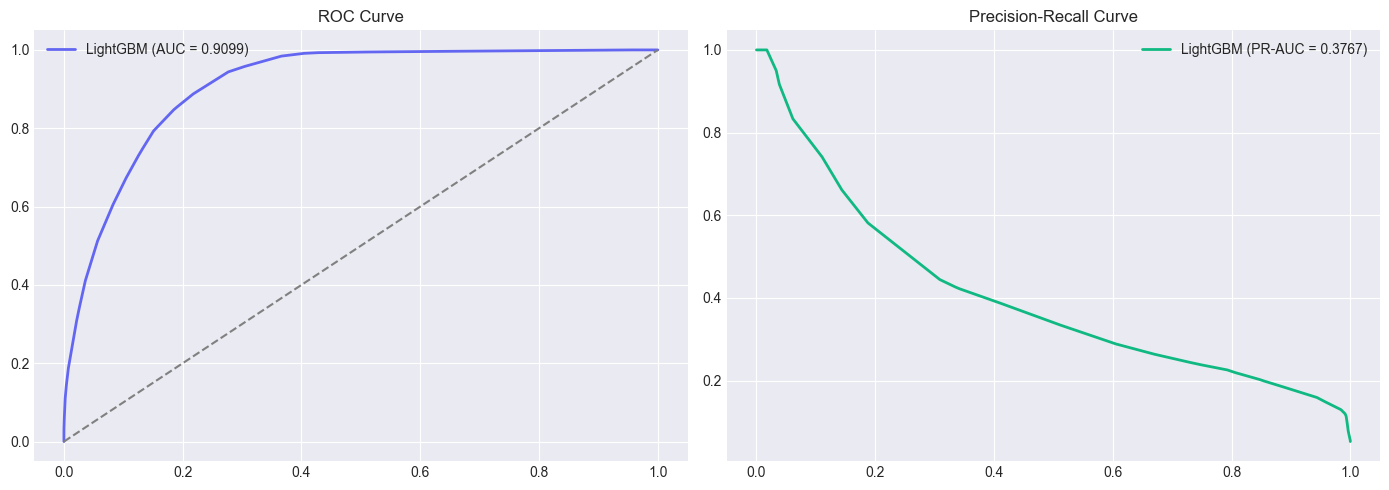

In [71]:
y_pred = (y_prob > best_th).astype(int)

roc_auc = float(roc_auc_score(y_val, y_prob))
pr_auc = float(average_precision_score(y_val, y_prob))
acc = float(accuracy_score(y_val, y_pred))
prec = float(precision_score(y_val, y_pred, zero_division=0))
rec = float(recall_score(y_val, y_pred, zero_division=0))
f1 = float(f1_score(y_val, y_pred, zero_division=0))
f2 = float(fbeta_score(y_val, y_pred, beta=2, zero_division=0))

approved_mask = (y_val == 0)
approved_recall = float((y_pred[approved_mask] == 0).sum() / approved_mask.sum())

print("================ MODEL PERFORMANCE METRICS ================")
print(f"ROC-AUC:                {roc_auc:.4f}")
print(f"PR-AUC (Avg Precision): {pr_auc:.4f}")
print(f"80% Recall Threshold:   {best_th:.4f}")
print(f"Accuracy:               {acc:.4f} ({acc*100:.2f}%)")
print(f"Precision (DECLINED):   {prec:.4f}")
print(f"Recall (DECLINED):      {rec:.4f} ({rec*100:.2f}% bad loans caught!)")
print(f"APPROVED Recall:        {approved_recall:.4f} ({approved_recall*100:.2f}%)")

# ROC & PR Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fpr, tpr, _ = roc_curve(y_val, y_prob)
axes[0].plot(fpr, tpr, color='#6366F1', lw=2, label=f'LightGBM (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[0].set_title('ROC Curve')
axes[0].legend()

precision_pts, recall_pts, _ = precision_recall_curve(y_val, y_prob)
axes[1].plot(recall_pts, precision_pts, color='#10B981', lw=2, label=f'LightGBM (PR-AUC = {pr_auc:.4f})')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()
plt.tight_layout()
plt.show()

## 13. Model Interpretation & Feature Importance

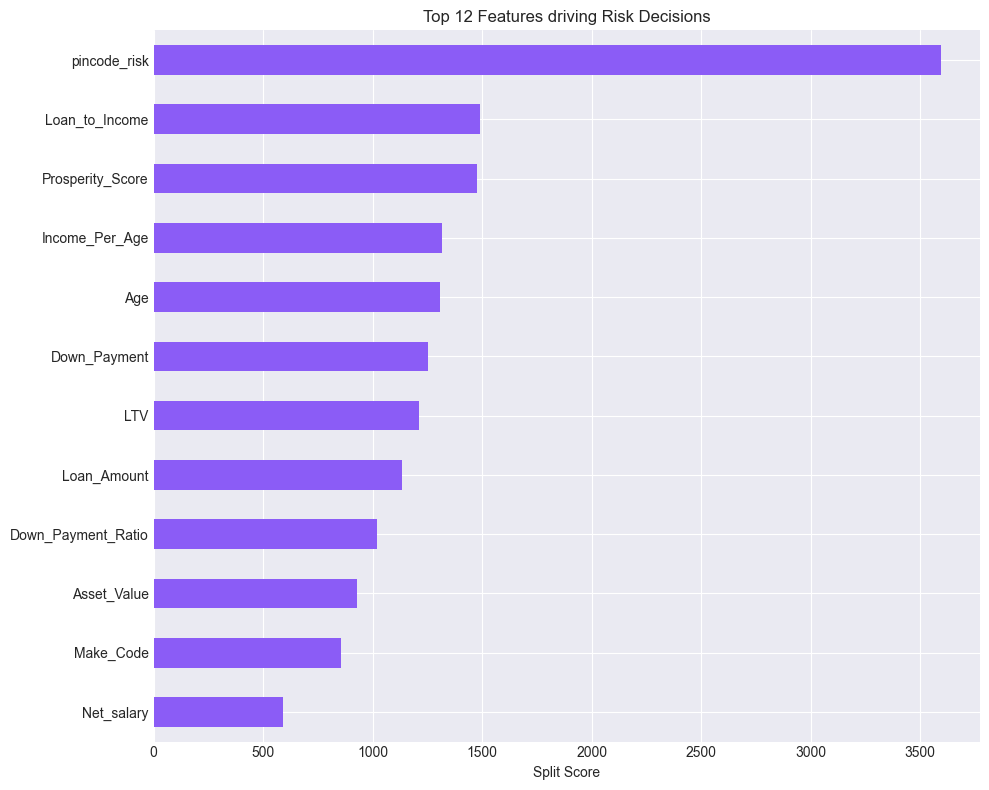

In [72]:
importances = pd.Series(base_model.feature_importances_, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
importances.tail(12).plot(kind='barh', color='#8B5CF6')
plt.title('Top 12 Features driving Risk Decisions')
plt.xlabel('Split Score')
plt.tight_layout()
plt.show()

## 14. Model Validation & Confusion Matrix

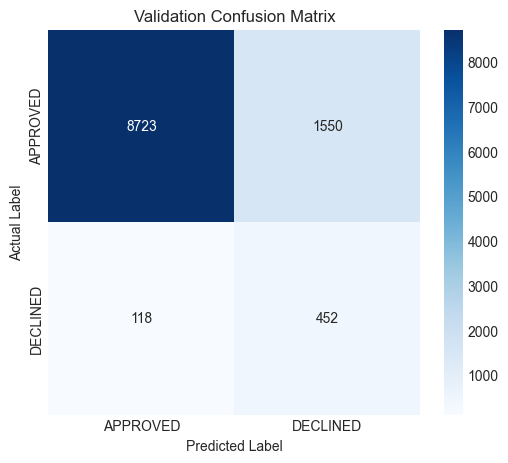

In [73]:
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['APPROVED', 'DECLINED'], yticklabels=['APPROVED', 'DECLINED'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Validation Confusion Matrix')
plt.show()

## 15. Model Deployment & Export Artifacts

In [74]:
MODEL_DIR = os.path.join(os.getcwd(), 'model')
os.makedirs(MODEL_DIR, exist_ok=True)

model_filepath = os.path.join(MODEL_DIR, 'lgbm_model.joblib')
metadata_filepath = os.path.join(MODEL_DIR, 'model_metadata.json')

joblib.dump(calibrated_model, model_filepath)

metadata = {
    'roc_auc': roc_auc,
    'pr_auc': pr_auc,
    'accuracy': acc,
    'precision': prec,
    'recall': rec,
    'f1_score': f1,
    'f2_score': f2,
    'approved_recall': approved_recall,
    'decision_threshold': best_th,
    'global_mean_decline': global_mean,
    'overall_prosperity_score': overall_pros,
    'median_age': median_age,
    'median_salary': median_salary,
    'feature_cols': feature_cols,
    'cat_cols': cat_cols,
    'importances': importances.to_dict(),
    'pincode_risk_dict': {str(int(k)): float(v) for k, v in pincode_risk_dict.items() if not np.isnan(k)},
    'make_risk_dict': {str(k): float(v) for k, v in make_risk_dict.items()},
    'pin_to_score': pin_to_score,
    'make_to_cc': make_to_cc
}

with open(metadata_filepath, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Model exported to {model_filepath}")
print(f"Metadata exported to {metadata_filepath}")

Model exported to /Users/chirag/.gemini/antigravity-ide/scratch/abc_credit_chatbot/model/lgbm_model.joblib
Metadata exported to /Users/chirag/.gemini/antigravity-ide/scratch/abc_credit_chatbot/model/model_metadata.json


## 16. Monitoring & Maintenance

- **API Endpoint**: Production FastAPI server deployed at `http://localhost:8000/api/evaluate-loan`.
- **Audit Trail**: Real-time logging of masked PII and predictions in `logs/audit_repository.jsonl`.
- **Performance & Drift Monitoring**: Monthly monitoring of Pincode risk shifts, average LTV, and default rate drift.